In [24]:
import pandas as pd
import random
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df = pd.read_excel('../lessons/Dry_Bean_Dataset.xlsx')

In [25]:
df.shape
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [26]:
X = df.drop(["Class"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm  = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_norm, y_train)

predictions   = model.predict(X_test_norm)
probabilities = model.predict_proba(X_test_norm)[:, 1] 

metrics = classification_report(y_test, predictions)

print(metrics)

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.91      0.92       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.95      0.94      0.94       317
    DERMASON       0.92      0.90      0.91       671
       HOROZ       0.97      0.96      0.97       408
       SEKER       0.97      0.94      0.95       413
        SIRA       0.85      0.90      0.87       536

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [27]:
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [28]:
class BeansDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# делим данные на ТРИ части: train / validation / test = 70 / 15 / 15
# stratify сохраняет пропорции классов (важно: BOMBAY редкий, его легко потерять)

# шаг 1: отделяем test (15% от всех данных)
train_val_df, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["Class"]
)

# шаг 2: из оставшихся 85% отделяем validation так, чтобы он был 15% от ИСХОДНОГО объёма
# доля от остатка = 0.15 / 0.85 ≈ 0.176
val_ratio = 0.15 / 0.85
train_df, val_df = train_test_split(
    train_val_df, test_size=val_ratio, random_state=42, stratify=train_val_df["Class"]
)

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

# кодируем названия классов в числа один раз по ПОЛНОМУ df,
# чтобы все три части использовали одну и ту же нумерацию
class_names = sorted(df["Class"].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

# признаки масштабируем: scaler учим ТОЛЬКО на train, применяем ко всем частям
nn_scaler = StandardScaler()
train_features = nn_scaler.fit_transform(train_df.drop(columns=["Class"]))  # fit только на train
val_features = nn_scaler.transform(val_df.drop(columns=["Class"]))           # только transform
test_features = nn_scaler.transform(test_df.drop(columns=["Class"]))         # только transform

train_labels = train_df["Class"].map(class_to_idx).values
val_labels = val_df["Class"].map(class_to_idx).values
test_labels = test_df["Class"].map(class_to_idx).values

training_data = BeansDataset(train_features, train_labels)
validation_data = BeansDataset(val_features, val_labels)
test_data = BeansDataset(test_features, test_labels)

# shuffle=True только для train — на val/test мы не учимся, порядок не важен
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(validation_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

train=9527  val=2042  test=2042


In [29]:
# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(16, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 7)

    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        x = nn.ReLU()(self.fc2(x))
        x = self.fc3(x)
        return x


model = GarmentClassifier()

loss_fn = torch.nn.CrossEntropyLoss()

In [30]:
# обучение с early stopping: следим за ошибкой на VALIDATION, а не на test.
# test не трогаем вообще — он для честной финальной оценки в самом конце.

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 700          # верхний предел; на практике остановимся раньше
patience = 30         # сколько эпох терпим без улучшения val_loss, прежде чем остановиться

train_losses = []     # копим ошибку за каждую эпоху — для графика
val_losses = []

best_val_loss = float("inf")
best_epoch = 0
best_state = None                 # сюда сохраняем веса лучшей эпохи
epochs_without_improve = 0

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for batch_features, batch_labels in train_dataloader:
        optimizer.zero_grad()               # обнуляем градиенты с прошлого шага

        outputs = model(batch_features)
        loss = loss_fn(outputs, batch_labels)

        loss.backward()                     # считаем градиенты (проход назад)
        optimizer.step()                    # подкручиваем веса

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # ошибка на validation — без обучения, чтобы отследить переобучение и решить, когда остановиться
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for batch_features, batch_labels in val_dataloader:
            outputs = model(batch_features)
            val_loss_sum += loss_fn(outputs, batch_labels).item()
    avg_val_loss = val_loss_sum / len(val_dataloader)
    val_losses.append(avg_val_loss)

    # early stopping: улучшился ли val_loss?
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}  # запоминаем лучшие веса
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epoch % 50 == 0 or epoch == 1:
        print(f"эпоха {epoch:>3}   train_loss = {avg_train_loss:.4f}   val_loss = {avg_val_loss:.4f}")

    if epochs_without_improve >= patience:
        print(f"\nОстановка на эпохе {epoch}: val_loss не улучшался {patience} эпох подряд.")
        break

# откатываемся к весам лучшей эпохи (а не к последним, уже переобученным)
model.load_state_dict(best_state)
print(f"Лучшая эпоха: {best_epoch}   best_val_loss = {best_val_loss:.4f}")

эпоха   1   train_loss = 1.1187   val_loss = 0.5031
эпоха  50   train_loss = 0.1739   val_loss = 0.1834

Остановка на эпохе 57: val_loss не улучшался 30 эпох подряд.
Лучшая эпоха: 27   best_val_loss = 0.1799


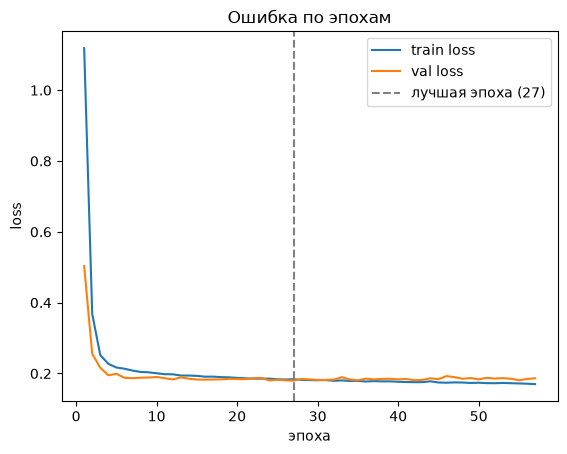

In [31]:
import matplotlib.pyplot as plt

# длина берётся из train_losses, потому что early stopping мог оборвать раньше 700 эпох
epochs_ran = range(1, len(train_losses) + 1)

plt.plot(epochs_ran, train_losses, label="train loss")
plt.plot(epochs_ran, val_losses, label="val loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"лучшая эпоха ({best_epoch})")
plt.xlabel("эпоха")
plt.ylabel("loss")
plt.title("Ошибка по эпохам")
plt.legend()
plt.show()

In [32]:
# ФИНАЛЬНАЯ проверка на test — эти данные модель не видела ни в обучении, ни в early stopping.
# Именно поэтому оценка тут честная. Запускаем этот блок один раз, в самом конце.

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():  # на инференсе градиенты не нужны — экономим память и время
    for batch_features, batch_labels in test_dataloader:
        outputs = model(batch_features)
        predicted_classes = outputs.argmax(dim=1)  # индекс класса с наибольшим баллом
        all_predictions.extend(predicted_classes.tolist())
        all_labels.extend(batch_labels.tolist())

predicted_names = [class_names[i] for i in all_predictions]
true_names = [class_names[i] for i in all_labels]

print(classification_report(true_names, predicted_names))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.92      0.93       198
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.93      0.95      0.94       245
    DERMASON       0.93      0.92      0.92       532
       HOROZ       0.97      0.94      0.96       289
       SEKER       0.94      0.96      0.95       304
        SIRA       0.87      0.88      0.87       396

    accuracy                           0.93      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.93      0.93      0.93      2042



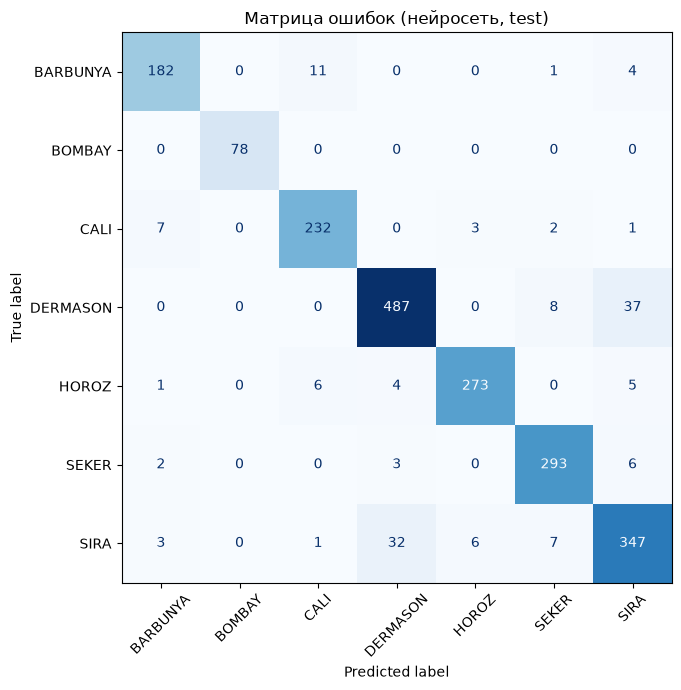

Топ перепутанных пар (истинный -> предсказанный):
    DERMASON -> SIRA        37 шт.
        SIRA -> DERMASON    32 шт.
    BARBUNYA -> CALI        11 шт.
    DERMASON -> SEKER       8 шт.
        CALI -> BARBUNYA    7 шт.


In [33]:
# матрица ошибок: показывает, какой класс с каким путается.
# по диагонали — правильные ответы, вне диагонали — ошибки.
# переиспользуем предсказания нейросети (true_names / predicted_names) из ячейки выше.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_names, predicted_names, labels=class_names)

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False
)
ax.set_title("Матрица ошибок (нейросеть, test)")
plt.tight_layout()
plt.show()

# самые частые перепутывания вне диагонали — где модель реально теряет F1
import numpy as np
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
print("Топ перепутанных пар (истинный -> предсказанный):")
for _ in range(5):
    i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
    if cm_off[i, j] == 0:
        break
    print(f"  {class_names[i]:>10} -> {class_names[j]:<10}  {cm_off[i, j]} шт.")
    cm_off[i, j] = 0